In [5]:
import pandas as pd

df = pd.read_csv("car_data.csv")

print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'car_data.csv'

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\user\Documents\Assignment3.ipynb
['.ipynb_checkpoints', '.venv', 'car-price-prediction', 'fundamentals.ipynb', 'fundamentals1.ipynb']


In [ ]:
import pandas as pd

df = pd.read_csv("car-price-prediction/car_data.csv")

print(df.shape)
print(df.head())

(301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [ ]:
print(df.info())
print()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB
None

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [6]:
print(df[["Year", "Kms_Driven", "Selling_Price"]].describe())

              Year     Kms_Driven  Selling_Price
count   301.000000     301.000000     301.000000
mean   2013.627907   36947.205980       4.661296
std       2.891554   38886.883882       5.082812
min    2003.000000     500.000000       0.100000
25%    2012.000000   15000.000000       0.900000
50%    2014.000000   32000.000000       3.600000
75%    2016.000000   48767.000000       6.000000
max    2018.000000  500000.000000      35.000000


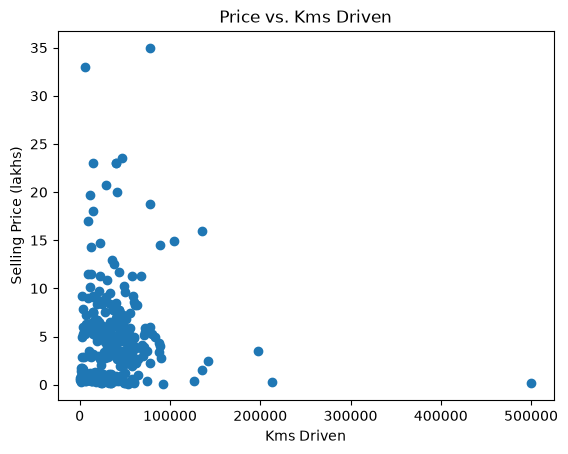

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["Kms_Driven"], df["Selling_Price"])
plt.xlabel("Kms Driven")
plt.ylabel("Selling Price (lakhs)")
plt.title("Price vs. Kms Driven")
plt.show()

In [9]:
print(df[df["Kms_Driven"] > 400000])

      Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
196  Activa 3g  2008           0.17           0.52      500000    Petrol   

    Seller_Type Transmission  Owner  
196  Individual    Automatic      0  


In [10]:

df_clean = df[df["Kms_Driven"] <= 400000].copy()

print(df_clean.shape)


(300, 9)


In [11]:
from sklearn.model_selection import train_test_split

X = df_clean[["Year", "Kms_Driven"]]
y = df_clean["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(240, 2)
(60, 2)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression")
print("MAE:", lr_mae)
print("R²:", lr_r2)

Linear Regression
MAE: 3.015345768013048
R²: 0.1701363427637851


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE:", rf_mae)
print("R²:", rf_r2)

Random Forest
MAE: 3.4657169047619054
R²: -0.13843339196142979
